In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
df = pd.read_csv("/kaggle/input/datasets/gauravsrivastav2507/tweets/Tweets.csv")
print(df.head())

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  


In [5]:
df = df[['text','sentiment']]
print(df.head())

                                                text sentiment
0                I`d have responded, if I were going   neutral
1      Sooo SAD I will miss you here in San Diego!!!  negative
2                          my boss is bullying me...  negative
3                     what interview! leave me alone  negative
4   Sons of ****, why couldn`t they put them on t...  negative


In [6]:
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

In [7]:
print(df['sentiment'])

0        1
1        0
2        0
3        0
4        0
        ..
27476    0
27477    0
27478    2
27479    2
27480    1
Name: sentiment, Length: 27481, dtype: int64


In [8]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)   # remove links
    text = re.sub(r'@\w+', '', text)      # remove mentions
    text = re.sub(r'[^a-zA-Z ]', '', text) # remove special chars
    return text

df['text'] = df['text'].fillna('').astype(str)
df['text'] = df['text'].apply(clean_text)

In [9]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['text'])

X = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(X, maxlen=100)

y = df['sentiment']

In [10]:
print(df['text'].isnull().sum())

0


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',     # watch validation performance
    patience=2,            # stop after 2 bad epochs
    restore_best_weights=True
)

In [13]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.1753007217321572), 1: np.float64(0.8215246636771301), 2: np.float64(1.0730707277785914)}


In [14]:
rnn_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')   # 3 sentiments
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1775639250.296246      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Epoch 1/10


I0000 00:00:1775639252.358186     104 service.cc:152] XLA service 0x78dd3c0043d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775639252.358299     104 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775639252.823192     104 cuda_dnn.cc:529] Loaded cuDNN version 91002


 18/344 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3268 - loss: 1.1029

I0000 00:00:1775639254.054985     104 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


344/344 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.4388 - loss: 1.0159 - val_accuracy: 0.6256 - val_loss: 0.8087
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7175 - loss: 0.6603 - val_accuracy: 0.6747 - val_loss: 0.7535
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8398 - loss: 0.4253 - val_accuracy: 0.6622 - val_loss: 0.8495
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9150 - loss: 0.2504 - val_accuracy: 0.6294 - val_loss: 1.0484


In [16]:
lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4926 - loss: 0.9733 - val_accuracy: 0.7024 - val_loss: 0.7088
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7371 - loss: 0.6233 - val_accuracy: 0.7160 - val_loss: 0.6718
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7823 - loss: 0.5388 - val_accuracy: 0.7151 - val_loss: 0.6776
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8050 - loss: 0.4875 - val_accuracy: 0.7077 - val_loss: 0.7241


In [18]:
gru_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=100),
    GRU(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4947 - loss: 0.9601 - val_accuracy: 0.6951 - val_loss: 0.7112
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7368 - loss: 0.6270 - val_accuracy: 0.7158 - val_loss: 0.6774
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7816 - loss: 0.5309 - val_accuracy: 0.7117 - val_loss: 0.6897
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8133 - loss: 0.4710 - val_accuracy: 0.7122 - val_loss: 0.7263


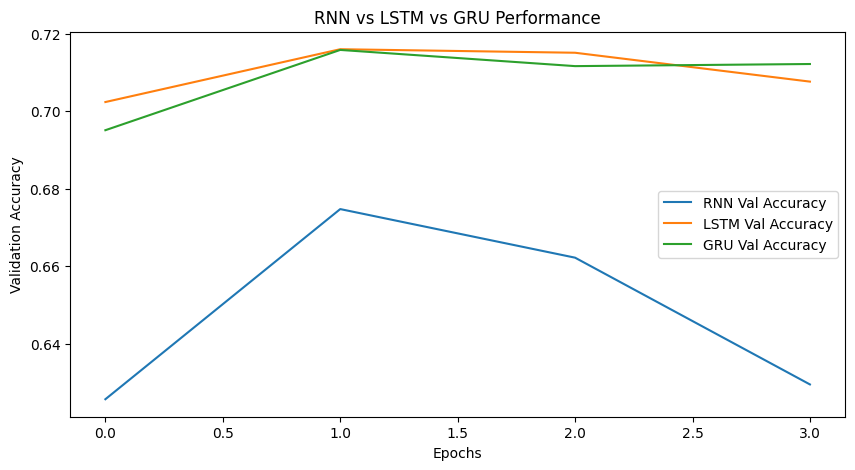

In [20]:
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['val_accuracy'], label='RNN Val Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='GRU Val Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('RNN vs LSTM vs GRU Performance')
plt.legend()

plt.show()